In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://media.githubusercontent.com/media/suhani-pandey/Assignment1_SocialDataAnalysis/refs/heads/main/SF_Crime_Merged_FINAL_CLEAN_2003_2026.csv"
df = pd.read_csv(url, low_memory=False)
print(df.shape)


(2906890, 22)


In [12]:
# Normalize categories fully
df["cat_clean"] = (
    df["Incident Category"]
    .astype(str)
    .str.upper()
    .str.replace("/", " ", regex=False)
    .str.replace("  ", " ", regex=False)
    .str.strip()
)

focus_crimes = [
    "ASSAULT",
    "BURGLARY",
    "LARCENY THEFT",
    "MOTOR VEHICLE THEFT",
    "ROBBERY"
]



yearly = (
    df[df["cat_clean"].isin(focus_crimes)]
    .groupby(["year", "cat_clean"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print("Years in plot:", yearly.index.min(), "-", yearly.index.max())



Years in plot: 2003 - 2026


## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

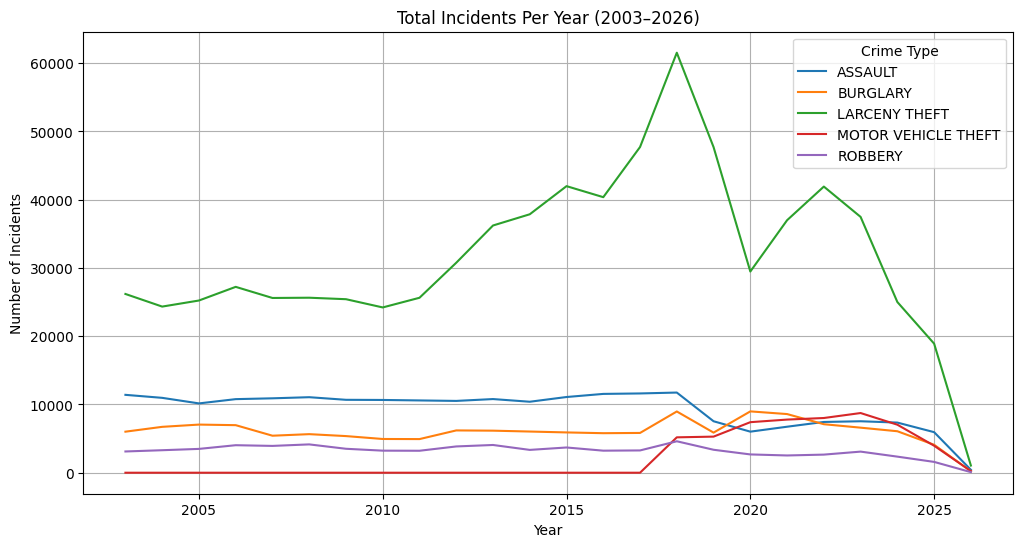

In [ ]:

yearly.plot(figsize=(12,6))
plt.title("Total Incidents Per Year (2003–2026)")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.legend(title="Crime Type")
plt.grid(True)
plt.show()

#Excerise 1.1
The temporal trends from 2003 to 2025 reveal several important patterns across the selected focus crimes.
LONG-TERM TREND IN LARCENY THEFT
Larceny Theft is consistently the most frequent crime category throughout the entire period.It increases steadily from the early 2010s and peaks dramatically around 2017-2018,reaching over 60,000 incidents.After this peak,it declines sharply in 2020 before partially recovering and then decreasing again in recent years.The continued decline after 2023 may reflect changes in policing ,reporting practices ,or incomplete data for the most recent years.

COVID-19 IMPACT IN 2020
Nearly all crime categories show a noticeable drop in 2020.This is especially visible in Larceny Theft and Assault.The timing strongly suggests the impact of the COVID-19 pandemic,when lockdown measures reduced public movement and social interaction.With fewer people in public spaces, opportunities for theft,robbery, and interpersonal conflict decreased.This supports the idea that crime rates are closely linked to routine activities and population mobility.

MOTOR VEHICLE THEFT INCREASE AFTER 2018
Motor Vechicle Theft increases significantly after 2018 compared to earlier years.This may reflect changing criminal patterns, increased vehicle ownership, or economic pressures influencing property-related crimes. 

In [4]:
# P(crime)
P_crime = (
    df[df["cat_clean"].isin(focus_crimes)]
    ["cat_clean"]
    .value_counts(normalize=True)
)

print(P_crime)

cat_clean
LARCENY THEFT          0.604844
ASSAULT                0.177152
BURGLARY               0.115121
ROBBERY                0.060429
MOTOR VEHICLE THEFT    0.042455
Name: proportion, dtype: float64


In [5]:
P_crime_given_dist = (
    df[df["cat_clean"].isin(focus_crimes)]
    .groupby(["Police District", "cat_clean"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
)

In [6]:
ratio = (P_crime_given_dist / P_crime).unstack()

ratio_focus = ratio[focus_crimes]

ratio_focus.head()

,cat_clean,ASSAULT,BURGLARY,LARCENY THEFT,MOTOR VEHICLE THEFT,ROBBERY
Police District,Police District,,,,,
BAYVIEW,BAYVIEW,1.780650,1.315036,0.720131,NaN,1.615126
Bayview,Bayview,0.902384,0.953388,0.719166,5.557886,0.983687
CENTRAL,CENTRAL,0.859722,0.933240,1.142806,NaN,0.811605
Central,Central,0.450563,0.786479,1.222873,1.204967,0.642712
INGLESIDE,INGLESIDE,1.677769,1.243917,0.745610,NaN,1.797188


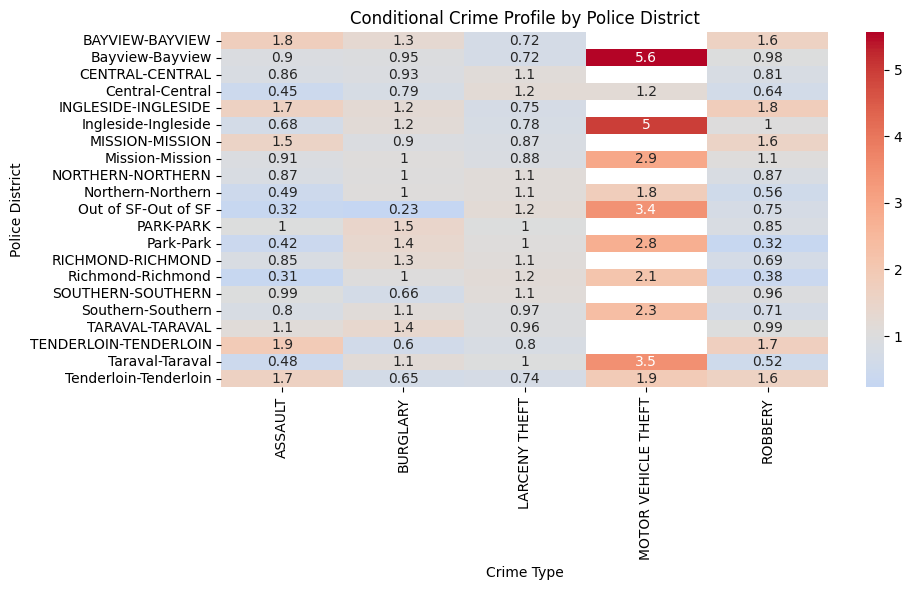

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(ratio, annot=True, cmap='coolwarm', center=1)

plt.title("Conditional Crime Profile by Police District")
plt.xlabel("Crime Type")
plt.ylabel("Police District")
plt.tight_layout()
plt.show()
